In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

2026-06-18 13:57:37.017584: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Matplotlib is building the font cache; this may take a moment.


In [6]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    'PlantVillage',
    shuffle = True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [4]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
len(dataset)

68

In [7]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())
    

(32, 256, 256, 3)
[1 0 0 0 0 1 1 1 2 0 0 0 0 0 1 1 1 1 1 2 0 0 0 1 0 1 0 1 1 0 2 0]


2026-06-18 14:13:20.995378: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch[0].numpy())


[[[103.  95. 106.]
  [118. 110. 121.]
  [114. 106. 117.]
  ...
  [112. 101. 115.]
  [120. 109. 123.]
  [121. 110. 124.]]

 [[103.  95. 106.]
  [128. 120. 131.]
  [107.  99. 110.]
  ...
  [116. 105. 119.]
  [123. 112. 126.]
  [115. 104. 118.]]

 [[106.  98. 109.]
  [122. 114. 125.]
  [ 93.  85.  96.]
  ...
  [123. 112. 126.]
  [126. 115. 129.]
  [112. 101. 115.]]

 ...

 [[161. 153. 166.]
  [161. 153. 166.]
  [161. 153. 166.]
  ...
  [151. 143. 158.]
  [155. 147. 162.]
  [161. 153. 168.]]

 [[160. 152. 165.]
  [160. 152. 165.]
  [161. 153. 166.]
  ...
  [149. 141. 156.]
  [153. 145. 160.]
  [161. 153. 168.]]

 [[161. 153. 166.]
  [161. 153. 166.]
  [162. 154. 167.]
  ...
  [148. 140. 155.]
  [153. 145. 160.]
  [161. 153. 168.]]]


2026-06-18 14:16:50.423574: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-06-18 14:24:08.628646: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


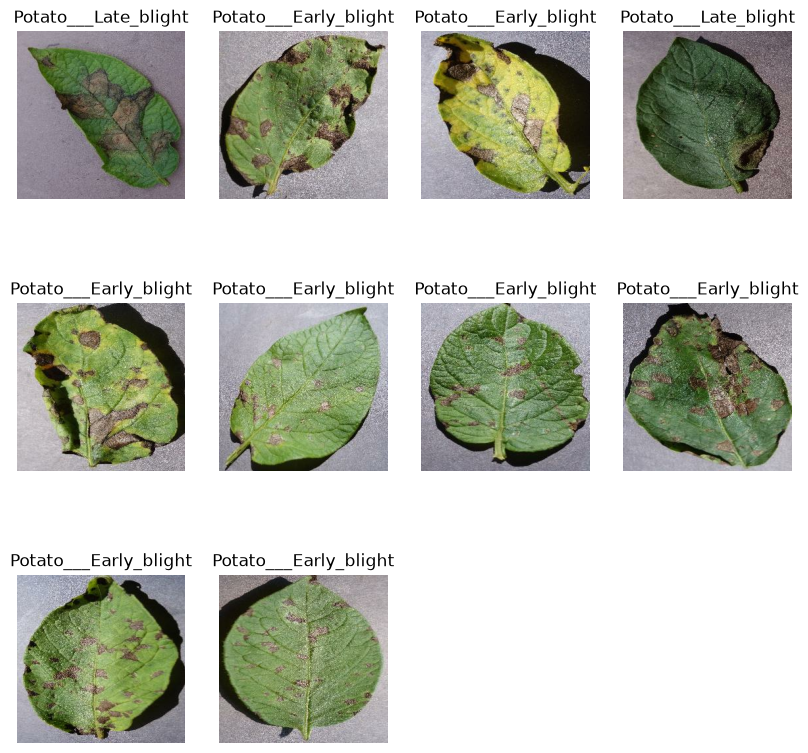

In [15]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(10):
        ax = plt.subplot(3, 4, i+1)
        plt.imshow(image_batch[i].numpy().astype('uint8'))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [17]:
train_size = 0.8 
len(dataset)*train_size

54.400000000000006

In [18]:
train_ds = dataset.take(54)
len(train_ds)


54

In [20]:
test_ds = dataset.skip(54)
len(test_ds)


14

In [21]:
val_size = 0.1
len(dataset)*val_size

6.800000000000001

In [22]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [23]:
test_ds = test_ds.skip(6)
len(test_ds)

8